In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
from sqlalchemy import create_engine

username = 'Equipo18'
password = 'E1q2u3i4p5o18'
host = '212.227.90.6'
database = 'Equip_18'

engine = create_engine(f"mysql+pymysql://{username}:{password}@{host}/{database}")

In [3]:
from sqlalchemy import inspect
inspector = inspect(engine)

tables = inspector.get_table_names()

for table in tables:
    df = pd.read_sql(f"SELECT * FROM {table}", engine)
    globals()[f'df_{table}'] = df  

In [4]:
df_BANK_marketing.head()

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,1,59.0,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,2,56.0,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,3,41.0,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,4,55.0,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,5,54.0,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


Estadisticas

In [5]:
df_BANK_marketing.describe()

,id,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11152.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,5581.500000,41.235384,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,3222.336187,11.914934,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,1.000000,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,2791.250000,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,5581.500000,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,8371.750000,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,11162.000000,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


Correlaciones

               age   balance       day  duration  campaign  previous
age       1.000000  0.112217 -0.000418  0.000139 -0.005358  0.020060
balance   0.112217  1.000000  0.010467  0.022436 -0.013894  0.030805
day      -0.000418  0.010467  1.000000 -0.018511  0.137007 -0.058981
duration  0.000139  0.022436 -0.018511  1.000000 -0.041557 -0.026716
campaign -0.005358 -0.013894  0.137007 -0.041557  1.000000 -0.049699
previous  0.020060  0.030805 -0.058981 -0.026716 -0.049699  1.000000


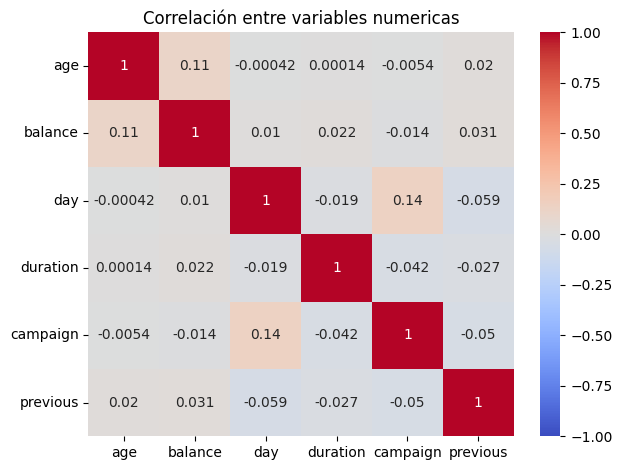

In [6]:
df_varnumericas=df_BANK_marketing[['age', 'balance', 'day', 'duration', 'campaign', 'previous']] 
correlation = df_varnumericas.corr() #saco la correlacion
print(correlation)

sns.heatmap(correlation,
            annot=True,           # esto me ayuda a mostrar los coeficientes
            cmap='coolwarm',      # paleta de colores
            vmin=-1, vmax=1)      # aca defino la escala de correlacion

plt.title('Correlación entre variables numericas', fontsize=12)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Histogramas

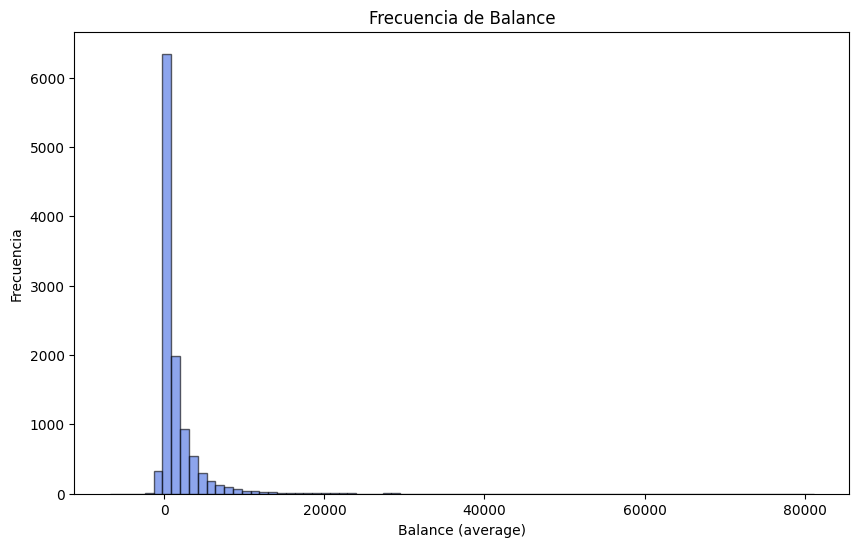

In [34]:
fig, ax = plt.subplots(figsize=(10, 6)) 

df_BANK_marketing["balance"].plot.hist(bins=80,
                                         color='royalblue',
                                        edgecolor='black',
                                        alpha=0.6,
                                        ax=ax)


ax.set_title("Frecuencia de Balance")
ax.set_xlabel("Balance (average)")
ax.set_ylabel("Frecuencia")
plt.show()

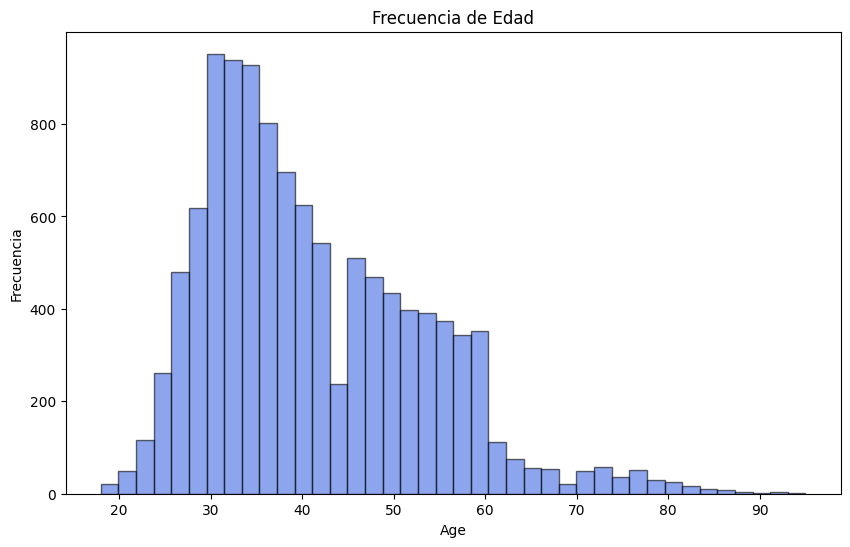

In [8]:
fig, ax = plt.subplots(figsize=(10, 6)) 

df_BANK_marketing["age"].plot.hist(bins=40,
                                         color='royalblue',
                                        edgecolor='black',
                                        alpha=0.6,
                                        ax=ax)


ax.set_title("Frecuencia de Edad")
ax.set_xlabel("Age")
ax.set_ylabel("Frecuencia")
plt.show()

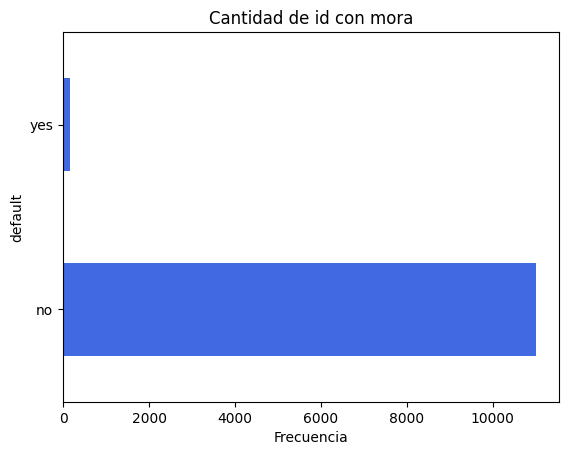

In [9]:
df_BANK_marketing["default"].value_counts().plot.barh(color='royalblue',            
                                                 title="Cantidad de id con mora",
                                                 xlabel="Frecuencia");

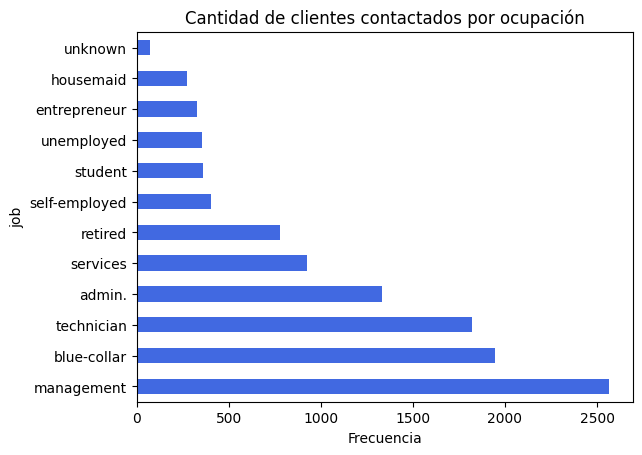

In [45]:
df_BANK_marketing["job"].value_counts().plot.barh(color='royalblue',            
                                                 title="Cantidad de clientes contactados por ocupación",
                                                 xlabel="Frecuencia");

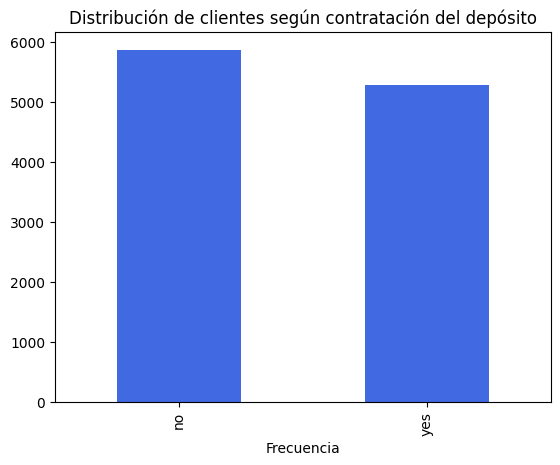

In [44]:

df_BANK_marketing["deposit"].value_counts().plot.bar(color='royalblue',            
                                                 title="Distribución de clientes según contratación del depósito",
                                                 xlabel="Frecuencia");